# Middle-Tier EfficientNetB0 implementation

This notebook uses the project dataset from `data/Dataset` for the binary `Fake` vs `Real` classification task. This version uses an EfficientNetB0 backbone with a custom classification head for the same train/validation/test workflow.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


In [2]:
# Load image data from the project data folder using the dataset's existing Train/Validation/Test split
IMAGE_SIZE = (128, 128)
SEED = 7
MAX_TRAIN_PER_CLASS = 6000
MAX_VAL_PER_CLASS = 1500
MAX_TEST_PER_CLASS = 1500
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'Dataset').exists():
            return candidate
    raise FileNotFoundError('Could not find data/Dataset from the current notebook location.')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data' / 'Dataset'
CLASS_NAMES = sorted([path.name for path in (DATA_ROOT / 'Train').iterdir() if path.is_dir()])
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}


def load_split(split_name, max_per_class=None):
    split_dir = DATA_ROOT / split_name
    rng = np.random.default_rng(SEED)
    images = []
    labels = []

    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        image_paths = sorted([
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

        if max_per_class is not None and len(image_paths) > max_per_class:
            selected_indices = np.sort(rng.choice(len(image_paths), size=max_per_class, replace=False))
            image_paths = [image_paths[index] for index in selected_indices]

        for image_path in image_paths:
            image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
            image = keras.utils.img_to_array(image)
            images.append(image)
            labels.append(CLASS_TO_INDEX[class_name])

    x = np.array(images, dtype='float32') / 255.0
    y = np.array(labels, dtype='int32')
    return x, y


x_train, y_train = load_split('Train', MAX_TRAIN_PER_CLASS)
x_val, y_val = load_split('Validation', MAX_VAL_PER_CLASS)
x_test, y_test = load_split('Test', MAX_TEST_PER_CLASS)

print('Project root:', PROJECT_ROOT)
print('Class names:', CLASS_NAMES)
print('x_train shape:', x_train.shape)
print('x_val shape:', x_val.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)


Project root: /Users/nathanjohnson/playground/COMP-487-Project-1
Class names: ['Fake', 'Real']
x_train shape: (12000, 128, 128, 3)
x_val shape: (3000, 128, 128, 3)
x_test shape: (3000, 128, 128, 3)
y_train shape: (12000,)
y_val shape: (3000,)
y_test shape: (3000,)


## Implement EfficientNetB0 for Fake vs Real classification

In [3]:
def build_efficientnet_b0(dropout_rate=0.3):
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    # Keep existing [0, 1] input pipeline and map to [0, 255] for pretrained EfficientNet.
    x = layers.Rescaling(255.0)(inputs)

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

    return keras.Model(inputs, outputs, name='EfficientNetB0Classifier')

In [4]:
model = build_efficientnet_b0(dropout_rate=0.3)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ rescaling[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)


Epoch 1/10
375/375 - 44s - 116ms/step - accuracy: 0.7002 - loss: 0.5765 - val_accuracy: 0.7670 - val_loss: 0.4902
Epoch 2/10
375/375 - 40s - 107ms/step - accuracy: 0.7428 - loss: 0.5185 - val_accuracy: 0.7343 - val_loss: 0.5083
Epoch 3/10
375/375 - 41s - 109ms/step - accuracy: 0.7520 - loss: 0.5034 - val_accuracy: 0.7747 - val_loss: 0.4734
Epoch 4/10
375/375 - 41s - 110ms/step - accuracy: 0.7552 - loss: 0.5001 - val_accuracy: 0.7710 - val_loss: 0.4735
Epoch 5/10
375/375 - 42s - 112ms/step - accuracy: 0.7573 - loss: 0.4917 - val_accuracy: 0.7787 - val_loss: 0.4668
Epoch 6/10
375/375 - 43s - 114ms/step - accuracy: 0.7581 - loss: 0.4937 - val_accuracy: 0.7640 - val_loss: 0.4759
Epoch 7/10
375/375 - 42s - 112ms/step - accuracy: 0.7553 - loss: 0.4955 - val_accuracy: 0.7713 - val_loss: 0.4664
Epoch 8/10
375/375 - 42s - 113ms/step - accuracy: 0.7594 - loss: 0.4908 - val_accuracy: 0.7797 - val_loss: 0.4624
Epoch 9/10
375/375 - 42s - 113ms/step - accuracy: 0.7608 - loss: 0.4928 - val_accuracy: 

In [6]:
# Evaluate training and testing accuracy
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f'Training accuracy:   {train_acc:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Testing accuracy:    {test_acc:.4f}')


Training accuracy:   0.7968
Validation accuracy: 0.7813
Testing accuracy:    0.6887


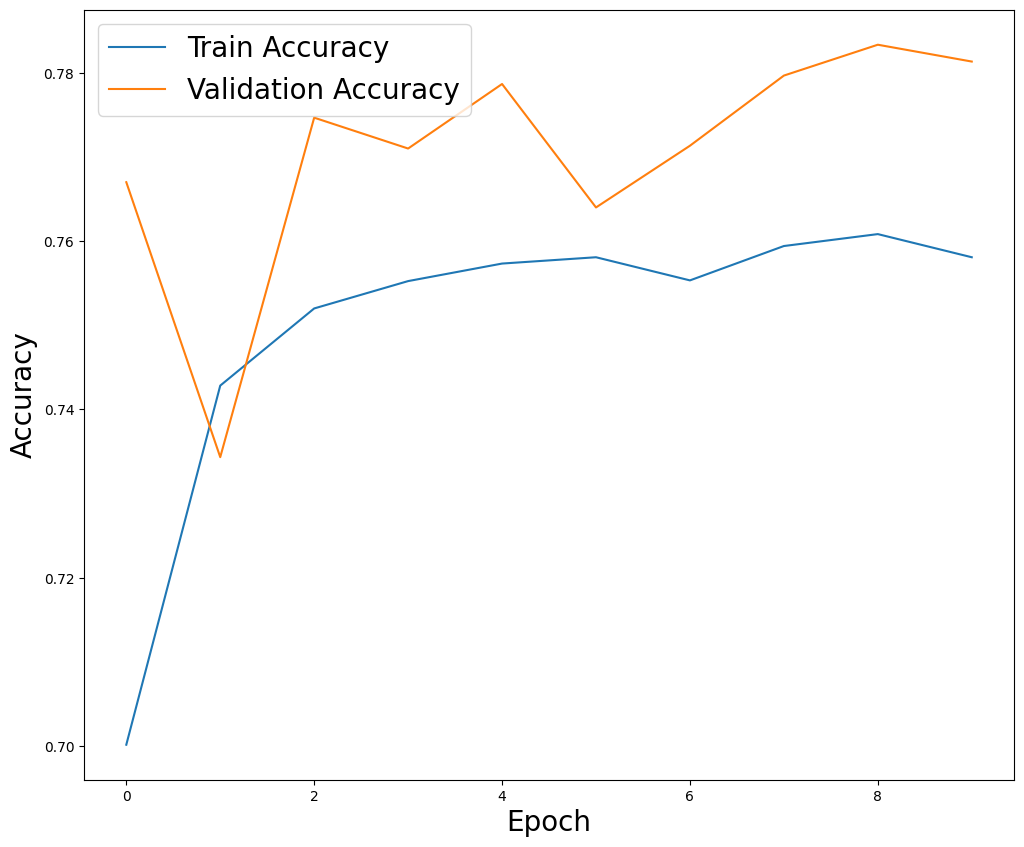

In [7]:
# Visualize training history
def plot_history(hist):
    plt.figure(figsize=(12, 10))
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
    plt.legend(loc='upper left', prop={'size': 20})
    plt.show()


hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
plot_history(hist)


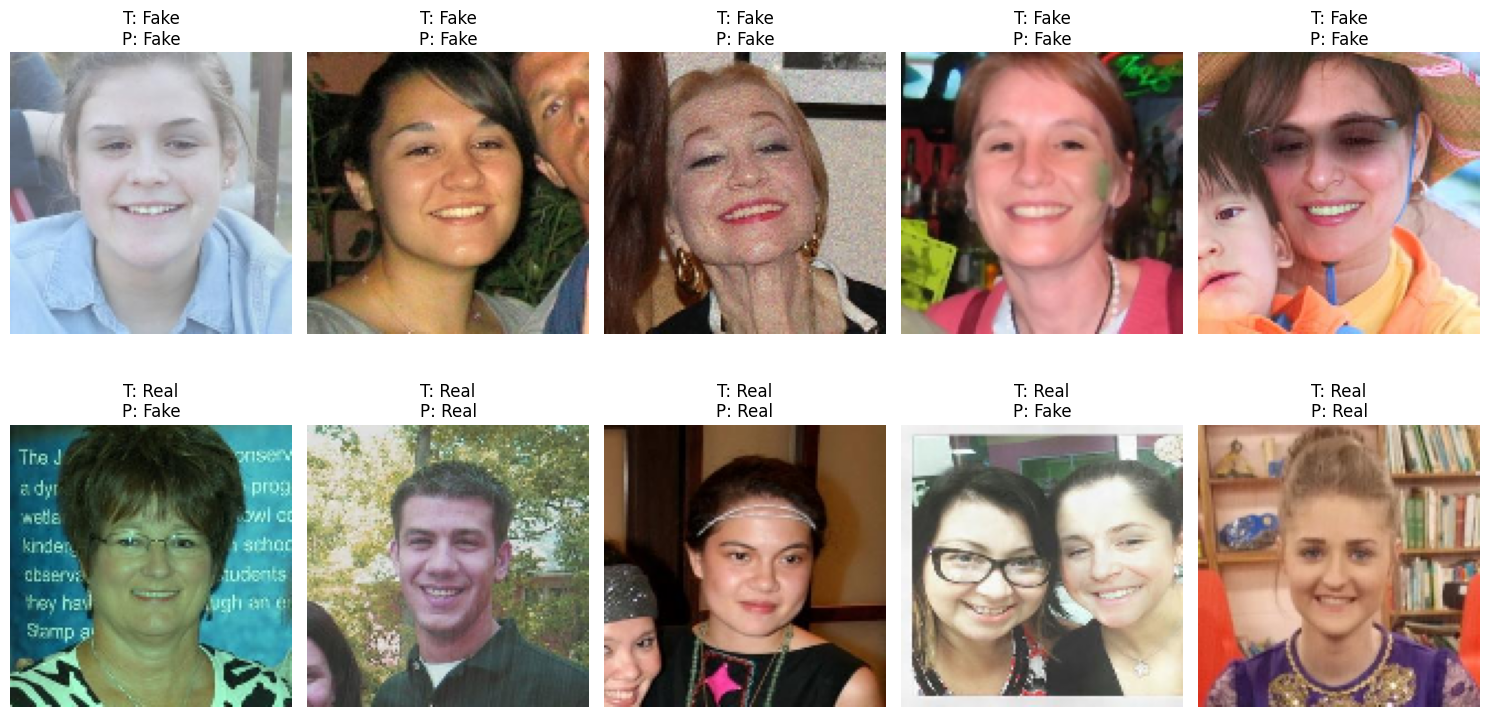

In [8]:
# Predict 5 real and 5 fake images from the test set
real_idx = np.where(y_test == CLASS_TO_INDEX['Real'])[0][:5]
fake_idx = np.where(y_test == CLASS_TO_INDEX['Fake'])[0][:5]
selected_idx = np.concatenate([fake_idx, real_idx])

images = x_test[selected_idx]
labels = y_test[selected_idx]

fig, ax = plt.subplots(2, 5, figsize=(15, 8))
ax = ax.flatten()

for i in range(10):
    img = images[i]
    true_label = labels[i]
    pred = model.predict(img[None, ...], verbose=0).argmax()

    ax[i].imshow(img)
    ax[i].set_title(
        f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred]}',
        fontsize=12
    )
    ax[i].axis('off')

plt.tight_layout()
plt.show()